In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def f_convex(x):
    return x**2 + 4*x - 5

def grad_f_convex(x):
    return 2*x + 4

In [27]:
def run_gd_convex(x0, lr, iterations=100):
    x = float(x0)
    xs = [x]
    for i in range(iterations):
        g = grad_f_convex(x)
        x = x - lr * g
        xs.append(x)
    return np.array(xs)

In [28]:
def f_nonconvex(x):
    return x**4 - 5*x**2 + 4*x

def grad_f_nonconvex(x):
    return 4*x**3 - 10*x + 4

In [29]:
def run_gd(x0, lr, iterations=200):
    x = float(x0)
    xs = [x]
    for _ in range(iterations):
        g = grad_f_nonconvex(x)
        x = x - lr * g
        xs.append(x)
    return np.array(xs)

In [30]:
def run_rmsprop(x0, lr=0.01, beta=0.9, eps=1e-8, iterations=200):
    x = float(x0)
    xs = [x]
    s = 0.0
    for _ in range(iterations):
        g = grad_f_nonconvex(x)
        s = beta * s + (1 - beta) * (g * g)
        x = x - lr * g / (np.sqrt(s) + eps)
        xs.append(x)
    return np.array(xs)

In [31]:
def run_adam(x0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, iterations=200):
    x = float(x0)
    xs = [x]
    m = 0.0
    v = 0.0
    for t in range(1, iterations + 1):
        g = grad_f_nonconvex(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)
        mhat = m / (1 - beta1**t)
        vhat = v / (1 - beta2**t)
        x = x - lr * mhat / (np.sqrt(vhat) + eps)
        xs.append(x)
    return np.array(xs)

In [ ]:
def plot_task1():
    x = 10.0
    iterations = 100
    lrs = [0.01, 0.1, 1.1]  
    labels = ['eta=0.01 (slow)', 'eta=0.1 (fast)', 'eta=1.1 (unstable)']
    colors = ['C0', 'C1', 'C3']

    trajectories = [run_gd_convex(x, lr, iterations) for lr in lrs]
    iters = np.arange(0, iterations + 1)

    plt.figure(figsize=(10, 4.5))
    for xs, lbl, c in zip(trajectories, labels, colors):
        plt.plot(iters, xs, label=lbl, color=c)
    plt.xlabel('Iteration')
    plt.ylabel('x')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4.5))
    xs_plot = np.linspace(-10, 12, 800)
    plt.plot(xs_plot, f_convex(xs_plot), color='0.75', label='f(x) curve')
    for xs, lbl, c in zip(trajectories, labels, colors):
        plt.plot(xs, f_convex(xs), '-o', markersize=3, label=lbl, color=c, alpha=0.9)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    for lr, xs in zip(lrs, trajectories):
        print(f"lr={lr}: final x={xs[-1]:.6f}, final f={f_convex(xs[-1]):.6f}")

In [ ]:
def plot_task2():
    inits = [2.0, -2.0]
    iterations = 200
    lr_gd = 0.01     
    lr_rms = 0.01
    lr_adam = 0.01

    for x in inits:
        gd = run_gd(x, lr=lr_gd, iterations=iterations)
        rms = run_rmsprop(x, lr=lr_rms, iterations=iterations)
        adam = run_adam(x, lr=lr_adam, iterations=iterations)

        iters = np.arange(0, iterations + 1)

        plt.figure(figsize=(10, 4.5))
        plt.plot(iters, gd, label=f'GD lr={lr_gd}', color='C0')
        plt.plot(iters, rms, label=f'RMSProp lr={lr_rms}', color='C1')
        plt.plot(iters, adam, label=f'Adam lr={lr_adam}', color='C2')
        plt.xlabel('Iteration')
        plt.ylabel('x')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4.5))
        plt.plot(iters, f_nonconvex(gd), label=f'GD lr={lr_gd}', color='C0')
        plt.plot(iters, f_nonconvex(rms), label=f'RMSProp lr={lr_rms}', color='C1')
        plt.plot(iters, f_nonconvex(adam), label=f'Adam lr={lr_adam}', color='C2')
        plt.xlabel('Iteration')
        plt.ylabel('f(x)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"  GD final x={gd[-1]:.6f}, f={f_nonconvex(gd[-1]):.6f}")
        print(f"  RMSProp final x={rms[-1]:.6f}, f={f_nonconvex(rms[-1]):.6f}")
        print(f"  Adam final x={adam[-1]:.6f}, f={f_nonconvex(adam[-1]):.6f}")

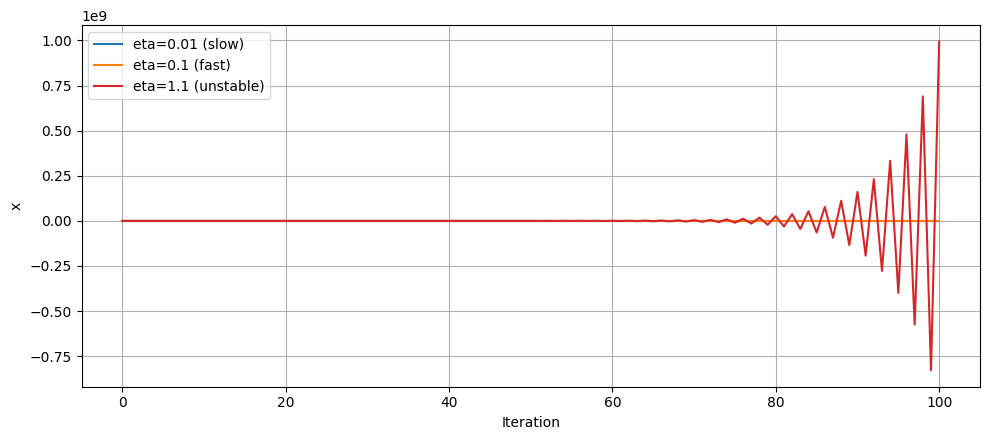

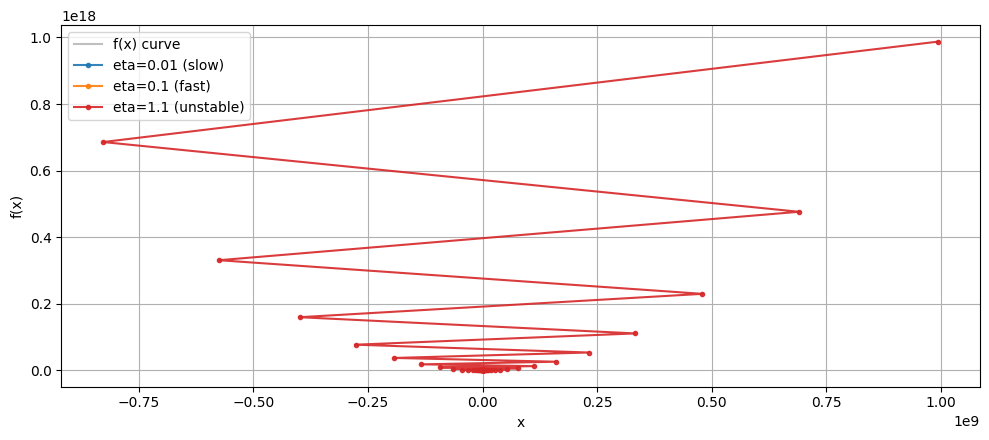

lr=0.01: final x=-0.408565, final f=-6.467336
lr=0.1: final x=-2.000000, final f=-9.000000
lr=1.1: final x=993815692.264188, final f=987669634165810048.000000


In [34]:
plot_task1()

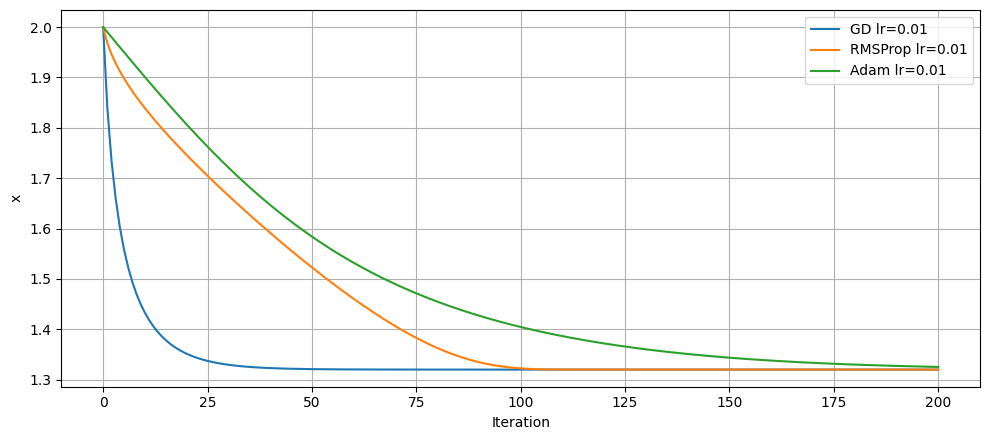

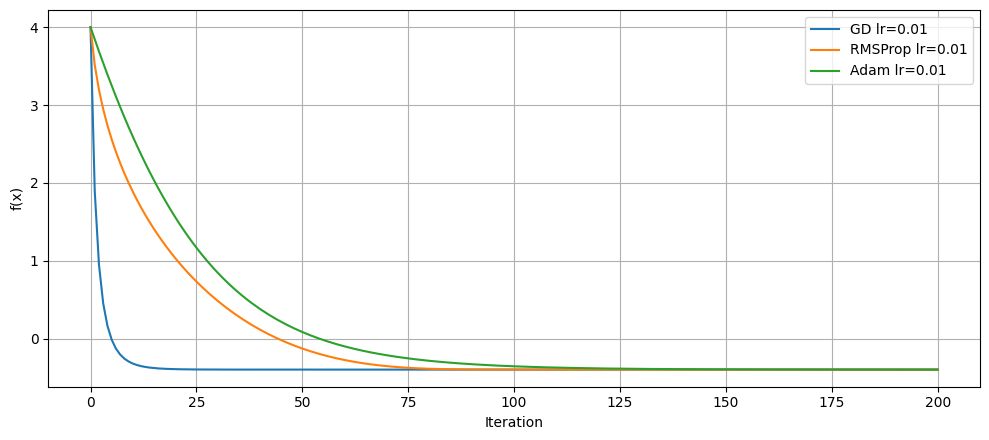

  GD final x=1.320012, f=-0.396042
  RMSProp final x=1.320012, f=-0.396042
  Adam final x=1.325272, f=-0.395891


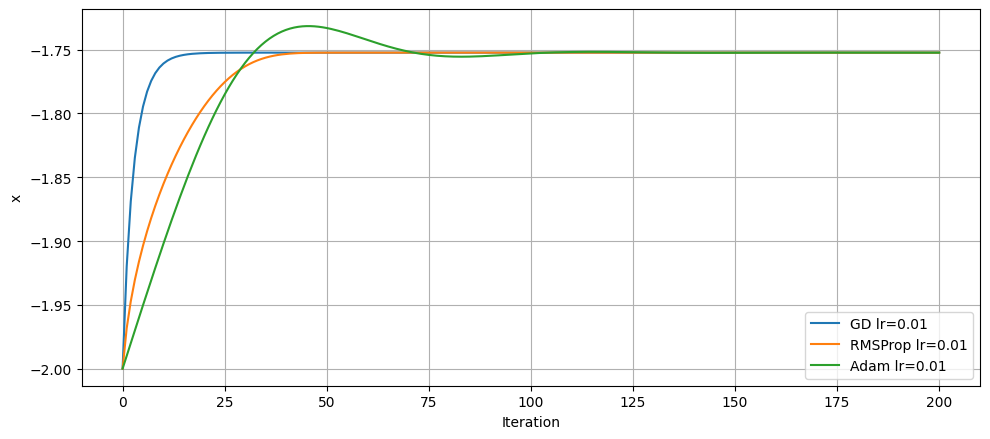

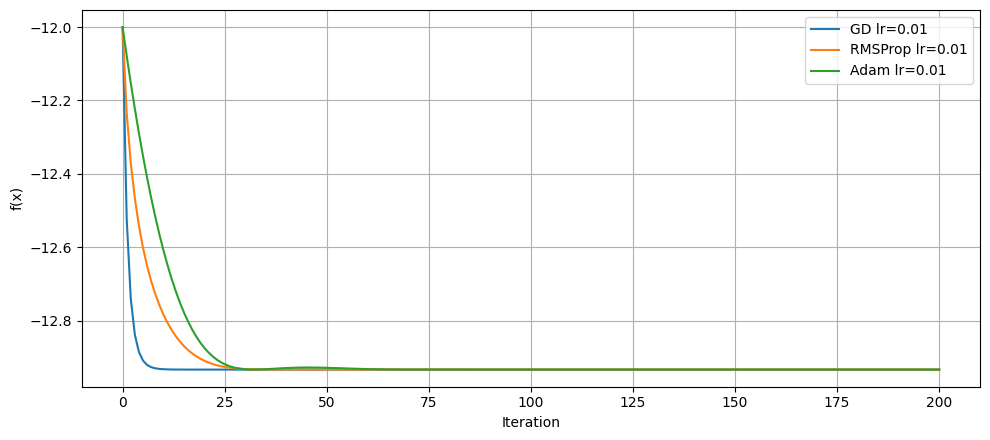

  GD final x=-1.752332, f=-12.933667
  RMSProp final x=-1.752332, f=-12.933667
  Adam final x=-1.752341, f=-12.933667


In [35]:
plot_task2()